In [1]:
import sys, os, subprocess, importlib.util, urllib.request

def ensure(module, pip_name=None):
    """pip-install a package only if it cannot be imported yet."""
    if importlib.util.find_spec(module) is None:
        print(f"Installing {pip_name or module} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or module], check=True)

ensure("ISLP", "ISLP")

# data files used by this lab (downloaded from the official ISLP_labs repository if missing)
BASE_URL = "https://raw.githubusercontent.com/intro-stat-learning/ISLP_labs/v2.2.3/"
for fname in ['Auto.csv', 'Auto.data']:
    if not os.path.exists(fname):
        os.makedirs(os.path.dirname(fname) or ".", exist_ok=True)
        urllib.request.urlretrieve(BASE_URL + fname, fname)

print("Setup complete – Python", sys.version.split()[0])



Installing ISLP ...
Setup complete – Python 3.13.14


In [2]:
# [ADDED] worked example – run this cell
# Environment check – run in each environment and include the output in your report
import sys, platform, importlib
print("Python version :", sys.version.split()[0])
print("Executable     :", sys.executable)
print("Operating sys. :", platform.system(), platform.release())
for pkg in ["numpy", "pandas", "matplotlib", "sklearn", "statsmodels", "ISLP"]:
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg:<12} {getattr(m, '__version__', 'installed')}")
    except ImportError:
        print(f"{pkg:<12} NOT INSTALLED – run the Setup cell / pip install ISLP")


Python version : 3.13.14
Executable     : C:\Users\HUY\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
Operating sys. : Windows 11
numpy        2.3.0
pandas       2.3.0
matplotlib   3.10.6
sklearn      1.8.0
statsmodels  0.15.0
ISLP         0.4.1


degree with the smallest test MSE: 7


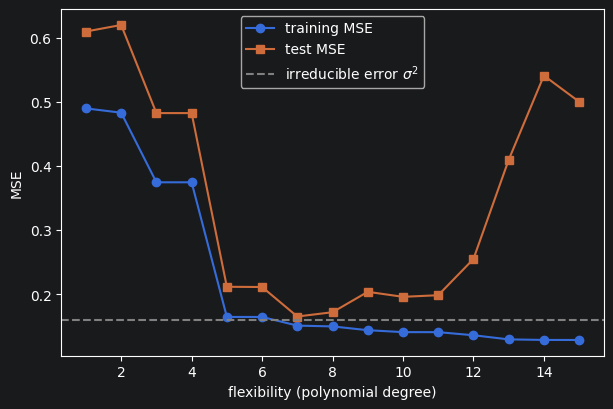

In [4]:
# [ADDED] worked example – run this cell
import numpy as np
from matplotlib.pyplot import subplots

rng = np.random.default_rng(171)
f = lambda x: np.sin(2 * x) + 0.5 * x            # the "true" regression function
n_train, n_test, sigma = 60, 2000, 0.4
x_tr = rng.uniform(-3, 3, n_train); y_tr = f(x_tr) + rng.normal(0, sigma, n_train)
x_te = rng.uniform(-3, 3, n_test);  y_te = f(x_te) + rng.normal(0, sigma, n_test)

degrees = range(1, 16)
train_mse, test_mse = [], []
for d in degrees:
    coef = np.polyfit(x_tr, y_tr, deg=d)            # least-squares polynomial of degree d
    train_mse.append(np.mean((y_tr - np.polyval(coef, x_tr))**2))
    test_mse.append(np.mean((y_te - np.polyval(coef, x_te))**2))

fig, ax = subplots(figsize=(7, 4.5))
ax.plot(degrees, train_mse, 'o-', label='training MSE')
ax.plot(degrees, test_mse, 's-', label='test MSE')
ax.axhline(sigma**2, ls='--', c='gray', label=r'irreducible error $\sigma^2$')
ax.set_xlabel('flexibility (polynomial degree)'); ax.set_ylabel('MSE'); ax.legend()
print("degree with the smallest test MSE:", degrees[int(np.argmin(test_mse))])

In [5]:
# [ADDED] worked example – run this cell
rng = np.random.default_rng(2)
n = 200
X_tr = np.vstack([rng.normal([0, 0], 1, (n, 2)), rng.normal([1.5, 1.5], 1, (n, 2))])
y_tr = np.repeat([0, 1], n)
X_te = np.vstack([rng.normal([0, 0], 1, (500, 2)), rng.normal([1.5, 1.5], 1, (500, 2))])
y_te = np.repeat([0, 1], 500)

def knn_predict(X_train, y_train, X_new, K):
    # squared Euclidean distances between every new point and every training point
    d2 = ((X_new[:, None, :] - X_train[None, :, :])**2).sum(axis=2)
    nearest = np.argsort(d2, axis=1)[:, :K]          # indices of the K closest points
    return (y_train[nearest].mean(axis=1) > 0.5).astype(int)   # majority vote

for K in [1, 5, 15, 51, 151, 301]:
    err = np.mean(knn_predict(X_tr, y_tr, X_te, K) != y_te)
    print(f"K = {K:>3d}:  test error rate = {err:.3f}")

K =   1:  test error rate = 0.207
K =   5:  test error rate = 0.147
K =  15:  test error rate = 0.144
K =  51:  test error rate = 0.140
K = 151:  test error rate = 0.132
K = 301:  test error rate = 0.132


In [6]:
# ✍️ Exercise 1 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import numpy as np

# (a) Tạo vector v = (2, 4, 6, ..., 40) và reshape thành ma trận 4x5
v = np.arange(2, 42, 2)
M = v.reshape(4, 5)

if M is not None:
    # (b) In shape, ndim, dtype và chuyển vị M.T
    print("--- (b) Attributes & Transpose ---")
    print(f"M.shape = {M.shape}, M.ndim = {M.ndim}, M.dtype = {M.dtype}")
    print("M.T (Transpose):\n", M.T)

    # (c) Trích xuất slicing (1-based counting: dòng 2 là index 1, cột cuối là index -1)
    print("\n--- (c) Slices ---")
    print("Second row (dòng 2):", M[1])
    print("Last column (cột cuối):", M[:, -1])
    print("Sub-matrix rows 2-3 & cols 1-3:\n", M[1:3, 0:3])

    # (d) Tính trung bình dòng và độ lệch chuẩn cột
    print("\n--- (d) Mean & Std with axis ---")
    print("Row means (axis=1):", M.mean(axis=1))
    print("Column std (axis=0):", M.std(axis=0))

    # (e) View vs Copy
    print("\n--- (e) View vs Copy ---")
    B = M[:2, :2]
    B[0, 0] = -1
    print("After B[0, 0] = -1, did M change?:", M[0, 0] == -1, f"(M[0, 0] is now {M[0, 0]})")

    # Khôi phục giá trị ban đầu và thử lại với .copy()
    M[0, 0] = 2
    B_copy = M[:2, :2].copy()
    B_copy[0, 0] = -1
    print("After B_copy[0, 0] = -1, did M change?:", M[0, 0] == -1, f"(M[0, 0] remains {M[0, 0]})")

--- (b) Attributes & Transpose ---
M.shape = (4, 5), M.ndim = 2, M.dtype = int64
M.T (Transpose):
 [[ 2 12 22 32]
 [ 4 14 24 34]
 [ 6 16 26 36]
 [ 8 18 28 38]
 [10 20 30 40]]

--- (c) Slices ---
Second row (dòng 2): [12 14 16 18 20]
Last column (cột cuối): [10 20 30 40]
Sub-matrix rows 2-3 & cols 1-3:
 [[12 14 16]
 [22 24 26]]

--- (d) Mean & Std with axis ---
Row means (axis=1): [ 6. 16. 26. 36.]
Column std (axis=0): [11.18033989 11.18033989 11.18033989 11.18033989 11.18033989]

--- (e) View vs Copy ---
After B[0, 0] = -1, did M change?: True (M[0, 0] is now -1)
After B_copy[0, 0] = -1, did M change?: False (M[0, 0] remains 2)


(slicing) trong NumPy tạo ra một view cùng chia sẻ vùng nhớ với ma trận gốc, do đó thay đổi trên B làm thay đổi trực tiếp ma trận M. Ngược lại, phương thức .copy() cấp phát một vùng nhớ độc lập hoàn toàn, giúp thay đổi trên mảng con không ảnh hưởng đến M.

Correlation between x and y: 0.9820


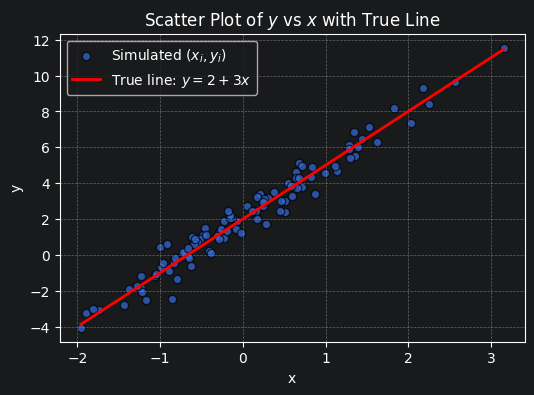

In [8]:
# ✍️ Exercise 2 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

# (a) Khởi tạo generator với seed 2026 và sinh dữ liệu
rng = np.random.default_rng(2026)
x = rng.standard_normal(100)
eps = rng.normal(0, 0.5, 100)

# (b) Tính y và độ tương quan giữa x và y
y = 2 + 3 * x + eps
corr = np.corrcoef(x, y)[0, 1]
print(f"Correlation between x and y: {corr:.4f}")

# (c) Vẽ đồ thị phân tán và đường hồi quy lý thuyết y = 2 + 3x
fig, ax = subplots(figsize=(6, 4))
ax.scatter(x, y, alpha=0.7, edgecolors='k', label='Simulated $(x_i, y_i)$')
x_grid = np.linspace(x.min(), x.max(), 100)
ax.plot(x_grid, 2 + 3 * x_grid, color='red', linewidth=2, label='True line: $y = 2 + 3x$')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Scatter Plot of $y$ vs $x$ with True Line")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

# Lưu figure với dpi = 150
fig.savefig("ex2_scatter.png", dpi=150)
plt.show()

hệ số tương quan(coef) của x và y rất cao(≈0.9820) phản ánh mối quan hệ tuyến tính giữa x và y.
≈0.9820) phản ánh mối quan hệ tuyến tính giữa x và y với độ nhiễu nhỏ với độ nhiễu nhỏ (σ=0.5). Đường hồi quy lý thuyết y = 2 + 3x (màu đỏ) đi qua các điểm dữ liệu một cách hợp lý, minh họa mối quan hệ tuyến tính giữa x và y.

In [9]:
# ✍️ Exercise 3 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import pandas as pd

Auto_raw = pd.read_csv("Auto.data", sep=r"\s+", na_values=["?"])
print("Auto_raw shape:", Auto_raw.shape)

# (a) Đếm số dòng có giá trị khuyết và loại bỏ bằng dropna()
n_missing = Auto_raw.isna().any(axis=1).sum()
print(f"Number of rows with missing values: {n_missing}")
Auto_clean = Auto_raw.dropna().copy()
print("Auto_clean shape:", Auto_clean.shape)

# (b) Phân loại biến và chuyển origin thành biến phân loại (categorical)
# Biến định lượng: mpg, cylinders, displacement, horsepower, weight, acceleration, year
# Biến định tính: origin, name
Auto_clean["origin"] = Auto_clean["origin"].map({1: "America", 2: "Europe", 3: "Japan"}).astype("category")
print("\nUnique origin categories:", Auto_clean["origin"].unique())

# (c) Bảng tóm tắt range, mean, std cho tất cả các biến định lượng
quantitative = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "year"]
stats_table = Auto_clean[quantitative].agg(["min", "max", "mean", "std"]).T
stats_table["range"] = stats_table["max"] - stats_table["min"]

print("\nSummary table of quantitative variables:")
print(stats_table[["range", "mean", "std"]])

Auto_raw shape: (397, 9)
Number of rows with missing values: 5
Auto_clean shape: (392, 9)

Unique origin categories: ['America', 'Japan', 'Europe']
Categories (3, object): ['America', 'Europe', 'Japan']

Summary table of quantitative variables:
               range         mean         std
mpg             37.6    23.445918    7.805007
cylinders        5.0     5.471939    1.705783
displacement   387.0   194.411990  104.644004
horsepower     184.0   104.469388   38.491160
weight        3527.0  2977.584184  849.402560
acceleration    16.8    15.541327    2.758864
year            12.0    75.979592    3.683737


Có chính xác 5 dòng dữ liệu chứa giá trị khuyết (ở cột horsepower), sau khi làm sạch còn lại 392 quan sát. Bộ dữ liệu gồm 7 biến định lượng và 2 biến định tính (name và origin).

In [10]:
# ✍️ Exercise 4 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import numpy as np
import pandas as pd

# Loại bỏ các quan sát từ 10 đến 85 (1-based), tương ứng chỉ số 9 đến 84 (0-based)
keep = np.r_[0:9, 85:len(Auto_clean)]
Auto_sub = Auto_clean.iloc[keep]
print(f"Auto_sub shape: {Auto_sub.shape} (removed {len(Auto_clean) - len(Auto_sub)} rows)")

# Tính lại range, mean, standard deviation
sub_stats = Auto_sub[quantitative].agg(["min", "max", "mean", "std"]).T
sub_stats["range"] = sub_stats["max"] - sub_stats["min"]

print("\nSubset statistics (range, mean, std):")
print(sub_stats[["range", "mean", "std"]])

# So sánh sự thay đổi giữa mẫu gốc và tập con
diff = sub_stats[["range", "mean", "std"]] - stats_table[["range", "mean", "std"]]
print("\nDifference (Subset - Full):")
print(diff)

Auto_sub shape: (316, 9) (removed 76 rows)

Subset statistics (range, mean, std):
               range         mean         std
mpg             35.6    24.404430    7.867283
cylinders        5.0     5.373418    1.654179
displacement   387.0   187.240506   99.678367
horsepower     184.0   100.721519   35.708853
weight        3348.0  2935.971519  811.300208
acceleration    16.3    15.726899    2.693721
year            12.0    77.145570    3.106217

Difference (Subset - Full):
              range       mean        std
mpg            -2.0   0.958512   0.062275
cylinders       0.0  -0.098521  -0.051605
displacement    0.0  -7.171483  -4.965637
horsepower      0.0  -3.747869  -2.782307
weight       -179.0 -41.612665 -38.102352
acceleration   -0.5   0.185572  -0.065143
year            0.0   1.165978  -0.577520


Các chỉ số thay đổi rõ rệt nhất là weight (giảm trung bình
41.6 và giảm range
179) cùng displacement và horsepower, trong khi mpg trung bình tăng xấp xỉ
+
+0.96. Nguyên nhân là các dòng bị loại (từ 10 đến 85) chủ yếu là các mẫu xe đời đầu thập niên 70 có động cơ to, thân xe nặng và tiêu hao nhiều nhiên liệu, nên việc loại bỏ chúng làm giảm độ nặng và tăng hiệu quả nhiên liệu trung bình của tập dữ liệu.

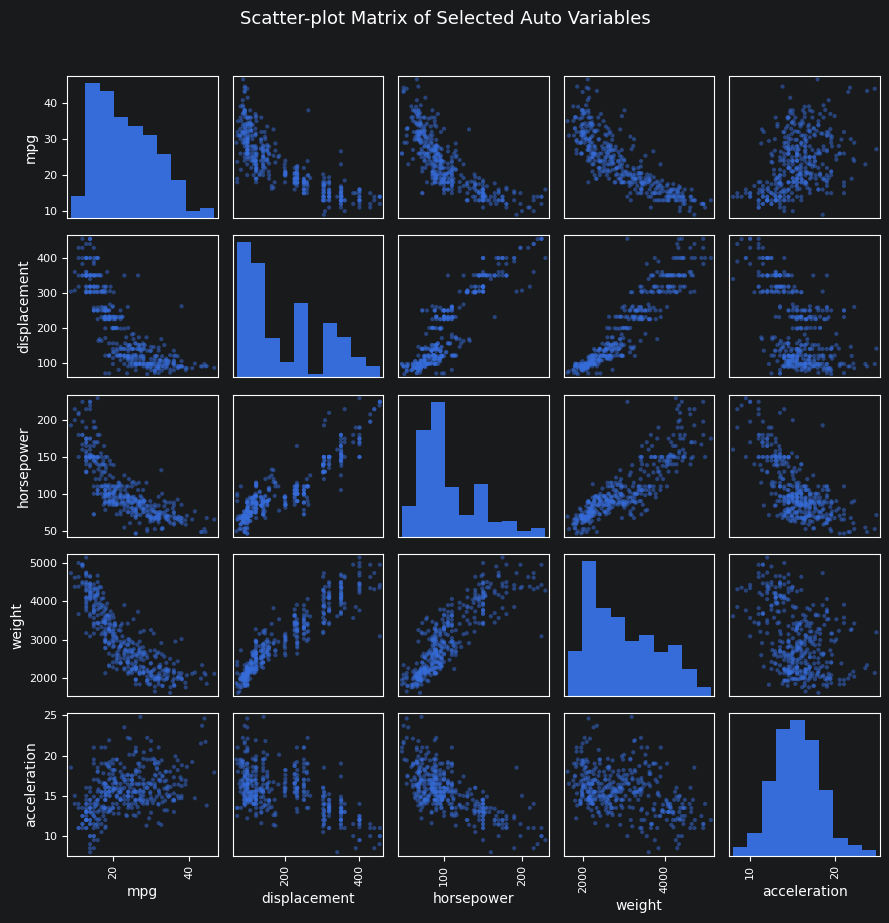

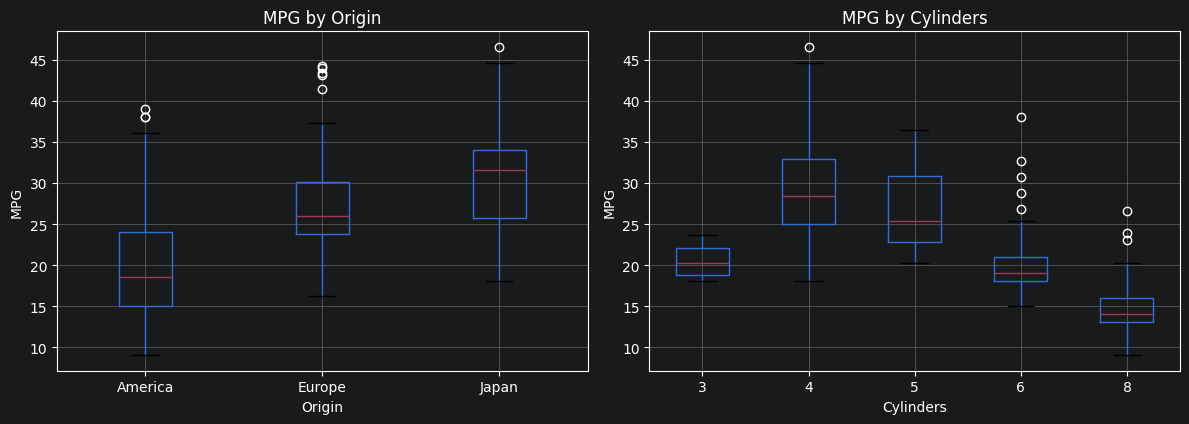

In [11]:
# ✍️ Exercise 5 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import pandas as pd

# (a) Ma trận biểu đồ phân tán (Scatter-plot matrix)
scatter_cols = ["mpg", "displacement", "horsepower", "weight", "acceleration"]
pd.plotting.scatter_matrix(Auto_clean[scatter_cols], figsize=(9, 9), diagonal="hist")
plt.suptitle("Scatter-plot Matrix of Selected Auto Variables", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# (b) Biểu đồ hộp song song (Side-by-side boxplots) cho mpg theo origin và cylinders
fig, axes = subplots(1, 2, figsize=(12, 4.5))
Auto_clean.boxplot("mpg", by="origin", ax=axes[0])
axes[0].set_title("MPG by Origin")
axes[0].set_xlabel("Origin")
axes[0].set_ylabel("MPG")

Auto_clean.boxplot("mpg", by="cylinders", ax=axes[1])
axes[1].set_title("MPG by Cylinders")
axes[1].set_xlabel("Cylinders")
axes[1].set_ylabel("MPG")

fig.suptitle("")  # Bỏ title mặc định của pandas
fig.tight_layout()
plt.show()

Mối quan hệ phi tuyến mạnh: weight, displacement, và horsepower có tương quan nghịch rất mạnh với mpg. Tuy nhiên, mối quan hệ này mang tính chất đường cong (phi tuyến / convex), nghĩa là khi xe rất nặng thì việc tăng thêm trọng lượng chỉ làm giảm nhẹ mpg so với xe nhẹ.
Ảnh hưởng của số xi-lanh: Xe 4 xi-lanh có mức mpg cao hơn đáng kể so với xe 6 và 8 xi-lanh; số xi-lanh là một biến dự đoán rất mạnh đối với mức tiêu thụ nhiên liệu.
Khác biệt theo xuất xứ: Xe xuất xứ từ Nhật Bản (Japan) và Châu Âu (Europe) có mức tiết kiệm nhiên liệu (mpg) vượt trội so với xe Mỹ (America).

College shape: (777, 18)

--- (a) First 5 rows ---
  Private  Apps  Accept  Enroll  Top10perc  Top25perc  F.Undergrad  \
0     Yes  1660    1232     721         23         52         2885   
1     Yes  2186    1924     512         16         29         2683   
2     Yes  1428    1097     336         22         50         1036   
3     Yes   417     349     137         60         89          510   
4     Yes   193     146      55         16         44          249   

   P.Undergrad  Outstate  Room.Board  Books  Personal  PhD  Terminal  \
0          537      7440        3300    450      2200   70        78   
1         1227     12280        6450    750      1500   29        30   
2           99     11250        3750    400      1165   53        66   
3           63     12960        5450    450       875   92        97   
4          869      7560        4120    800      1500   76        72   

   S.F.Ratio  perc.alumni  Expend  Grad.Rate  
0       18.1           12    7041         60  
1

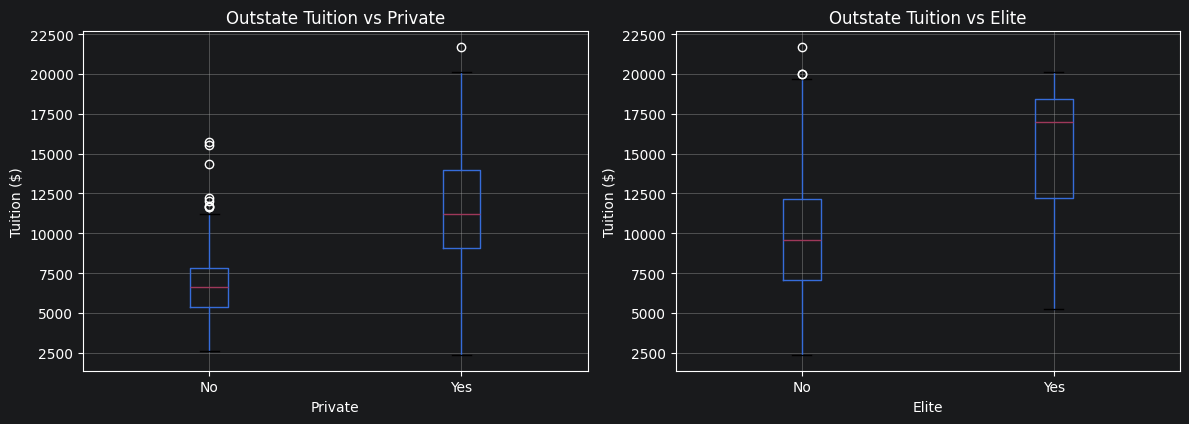

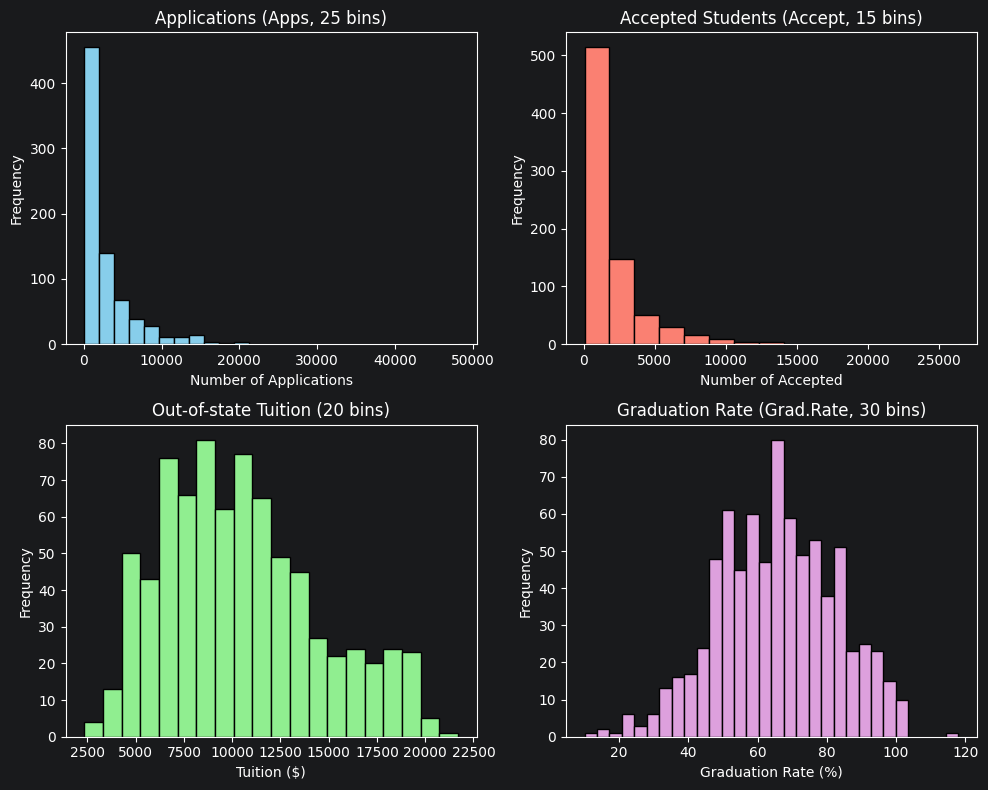

In [12]:
# ✍️ Exercise 6 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from ISLP import load_data

# Tải dữ liệu College
College = load_data("College")
print("College shape:", College.shape)

# (a) In 5 dòng đầu và thống kê mô tả describe()
print("\n--- (a) First 5 rows ---")
print(College.head())
print("\n--- Summary Statistics (describe) ---")
print(College.describe())

# (b) Số lượng trường đại học tư thục (Private)
n_private = (College["Private"] == "Yes").sum()
print(f"\n--- (b) Number of private colleges: {n_private} ---")

# (c) Tạo biến phân loại Elite (Top10perc > 50) và đếm số lượng
College["Elite"] = pd.Series("No", index=College.index)
College.loc[College["Top10perc"] > 50, "Elite"] = "Yes"
n_elite = (College["Elite"] == "Yes").sum()
print(f"\n--- (c) Number of elite colleges: {n_elite} ---")

# (d) Vẽ boxplot Outstate vs Private và Outstate vs Elite
fig, axes = subplots(1, 2, figsize=(12, 4.5))
College.boxplot("Outstate", by="Private", ax=axes[0])
axes[0].set_title("Outstate Tuition vs Private")
axes[0].set_xlabel("Private")
axes[0].set_ylabel("Tuition ($)")

College.boxplot("Outstate", by="Elite", ax=axes[1])
axes[1].set_title("Outstate Tuition vs Elite")
axes[1].set_xlabel("Elite")
axes[1].set_ylabel("Tuition ($)")

fig.suptitle("")
fig.tight_layout()
plt.show()

# (e) Lưới 2x2 biểu đồ histogram cho 4 biến định lượng với số lượng bins khác nhau
fig, axes = subplots(2, 2, figsize=(10, 8))
College["Apps"].plot.hist(ax=axes[0, 0], bins=25, edgecolor="black", color="skyblue")
axes[0, 0].set_title("Applications (Apps, 25 bins)")
axes[0, 0].set_xlabel("Number of Applications")

College["Accept"].plot.hist(ax=axes[0, 1], bins=15, edgecolor="black", color="salmon")
axes[0, 1].set_title("Accepted Students (Accept, 15 bins)")
axes[0, 1].set_xlabel("Number of Accepted")

College["Outstate"].plot.hist(ax=axes[1, 0], bins=20, edgecolor="black", color="lightgreen")
axes[1, 0].set_title("Out-of-state Tuition (20 bins)")
axes[1, 0].set_xlabel("Tuition ($)")

College["Grad.Rate"].plot.hist(ax=axes[1, 1], bins=30, edgecolor="black", color="plum")
axes[1, 1].set_title("Graduation Rate (Grad.Rate, 30 bins)")
axes[1, 1].set_xlabel("Graduation Rate (%)")

fig.tight_layout()
plt.show()

Có 565 trường đại học tư thục và 78 trường được xếp hạng "Elite" (học sinh thuộc top 10% phổ thông > 50%). Cả trường tư thục và trường tinh hoa đều có mức học phí ngoại bang (Outstate) cao hơn đáng kể so với các trường còn lại. Biểu đồ histogram cho thấy số lượng hồ sơ nộp (Apps) và trúng tuyển (Accept) phân phối lệch phải rõ rệt (right-skewed), trong khi tỷ lệ tốt nghiệp (Grad.Rate) và học phí (Outstate) có phân phối gần chuẩn (hình chuông).

In [15]:
# ✍️ Exercise 7 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
quantitative = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "year"]

for col in quantitative:
    mean_val = Auto_clean[col].mean()
    sd_val = Auto_clean[col].std()
    above_share = (Auto_clean[col] > mean_val).mean()
    print(f"{col:<12} mean = {mean_val:6.2f}  sd = {sd_val:6.2f}  above-mean share = {above_share:5.1%}")

mpg          mean =  23.45  sd =   7.81  above-mean share = 47.4%
cylinders    mean =   5.47  sd =   1.71  above-mean share = 47.4%
displacement mean = 194.41  sd = 104.64  above-mean share = 43.4%
horsepower   mean = 104.47  sd =  38.49  above-mean share = 37.8%
weight       mean = 2977.58  sd = 849.40  above-mean share = 43.4%
acceleration mean =  15.54  sd =   2.76  above-mean share = 45.7%
year         mean =  75.98  sd =   3.68  above-mean share = 54.1%


Đối với các biến có phân phối lệch phải như horsepower (tỷ lệ trên trung bình chỉ 37.8%) và displacement (43.4%), số lượng xe vượt mức trung bình ít hơn 50% do một lượng nhỏ xe có thông số cực lớn đã kéo giá trị trung bình lên cao. Ngược lại, biến year có hơn một nửa số quan sát (54.1%) nằm trên mức trung bình.

Results (degree d: (Bias^2, Variance)):
d =  1:  Bias^2 = 1.15608,  Variance = 0.01215,  Sum = 1.16823
d =  3:  Bias^2 = 0.45406,  Variance = 0.02900,  Sum = 0.48306
d =  5:  Bias^2 = 0.00817,  Variance = 0.01492,  Sum = 0.02310
d = 10:  Bias^2 = 0.00016,  Variance = 0.02500,  Sum = 0.02517
d = 15:  Bias^2 = 0.00000,  Variance = 0.04477,  Sum = 0.04477


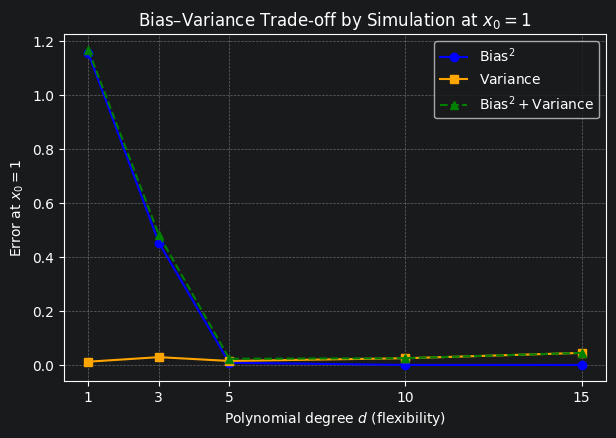

In [16]:
# ✍️ Exercise 8 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

# Thiết lập theo Worked Example 1
f = lambda x: np.sin(2 * x) + 0.5 * x   # Hàm thực tế
n_train = 60
sigma = 0.4
rng = np.random.default_rng(2026)

x0, n_rep = 1.0, 200
f_x0 = f(x0)
results = {}
degrees = [1, 3, 5, 10, 15]

for d in degrees:
    preds = []
    for r in range(n_rep):
        # Sinh tập huấn luyện mới kích thước 60
        x_tr = rng.uniform(-3, 3, n_train)
        y_tr = f(x_tr) + rng.normal(0, sigma, n_train)
        coef = np.polyfit(x_tr, y_tr, deg=d)
        preds.append(np.polyval(coef, x0))

    preds = np.array(preds)
    bias2 = float((np.mean(preds) - f_x0)**2)
    variance = float(np.var(preds))
    results[d] = (bias2, variance)

print("Results (degree d: (Bias^2, Variance)):")
for d, (b2, v) in results.items():
    print(f"d = {d:>2d}:  Bias^2 = {b2:.5f},  Variance = {v:.5f},  Sum = {b2+v:.5f}")

# Vẽ đồ thị Bias^2 và Variance theo bậc đa thức d
bias2_vals = [results[d][0] for d in degrees]
var_vals = [results[d][1] for d in degrees]

fig, ax = subplots(figsize=(7, 4.5))
ax.plot(degrees, bias2_vals, "o-", color="blue", label=r"$\mathrm{Bias}^2$")
ax.plot(degrees, var_vals, "s-", color="orange", label=r"$\mathrm{Variance}$")
ax.plot(degrees, [b + v for b, v in zip(bias2_vals, var_vals)], "^--", color="green", label=r"$\mathrm{Bias}^2 + \mathrm{Variance}$")

ax.set_xlabel("Polynomial degree $d$ (flexibility)")
ax.set_ylabel("Error at $x_0 = 1$")
ax.set_title(r"Bias–Variance Trade-off by Simulation at $x_0 = 1$")
ax.set_xticks(degrees)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()

Kết quả mô phỏng cho thấy khi bậc đa thức d tăng, Bias^2 giảm mạnh (mô hình trở nên linh hoạt hơn), trong khi Variance tăng (mô hình trở nên nhạy cảm với dữ liệu huấn luyện). Tổng lỗi (Bias^2 + Variance) đạt giá trị tối thiểu ở một bậc đa thức trung gian (d = 5 hoặc 10), minh họa rõ ràng trade-off giữa bias và variance trong học máy.

Đồ thị hoàn toàn khớp với lý thuyết: khi độ linh hoạt tăng (bậc đa thức
d tăng),
Bias
2
 giảm mạnh từ
1.156 xuống xấp xỉ
0. Ngược lại, phương sai (
Variance
Variance) có xu hướng tăng ở các bậc cao (
d=10,15) do mô hình bị overfitting vào nhiễu ngẫu nhiên, tạo nên đường cong tổng lỗi dạng chữ U đạt tối ưu ở mức bậc trung bình (
d≈5).

Optimal K = 90 with minimum test error rate = 0.1260
At K = 1:  Training error = 0.0000, Test error = 0.2070


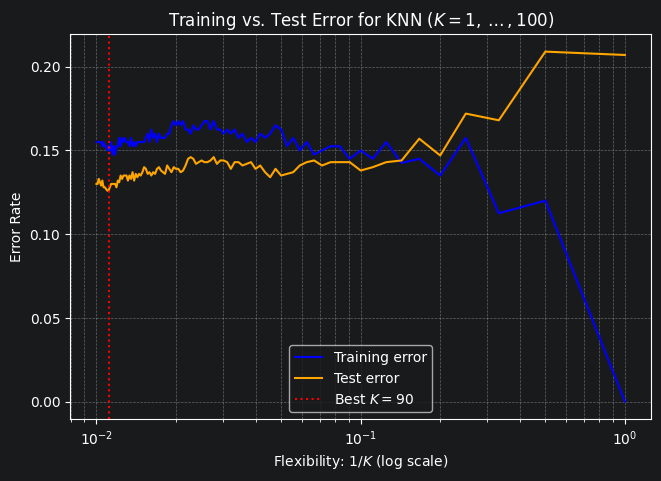

In [17]:
# ✍️ Exercise 9 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

# Tái lập dữ liệu từ Worked Example 2
rng = np.random.default_rng(2)
n = 200
X_tr = np.vstack([rng.normal([0, 0], 1, (n, 2)), rng.normal([1.5, 1.5], 1, (n, 2))])
y_tr = np.repeat([0, 1], n)
X_te = np.vstack([rng.normal([0, 0], 1, (500, 2)), rng.normal([1.5, 1.5], 1, (500, 2))])
y_te = np.repeat([0, 1], 500)

def knn_predict(X_train, y_train, X_new, K):
    d2 = ((X_new[:, None, :] - X_train[None, :, :])**2).sum(axis=2)
    nearest = np.argsort(d2, axis=1)[:, :K]
    return (y_train[nearest].mean(axis=1) > 0.5).astype(int)

Ks = list(range(1, 101))
train_err, test_err = [], []

# Lặp qua các giá trị K và tính tỷ lệ lỗi
for K in Ks:
    pred_tr = knn_predict(X_tr, y_tr, X_tr, K)
    pred_te = knn_predict(X_tr, y_tr, X_te, K)
    train_err.append(np.mean(pred_tr != y_tr))
    test_err.append(np.mean(pred_te != y_te))

best_idx = int(np.argmin(test_err))
best_K = Ks[best_idx]
print(f"Optimal K = {best_K} with minimum test error rate = {test_err[best_idx]:.4f}")
print(f"At K = 1:  Training error = {train_err[0]:.4f}, Test error = {test_err[0]:.4f}")

# Vẽ đồ thị tỷ lệ lỗi theo 1/K (trục hoành log scale tương tự Hình 2.17 sách ISLR)
inv_K = [1.0 / K for K in Ks]

fig, ax = subplots(figsize=(7.5, 5))
ax.plot(inv_K, train_err, color="blue", label="Training error")
ax.plot(inv_K, test_err, color="orange", label="Test error")
ax.set_xscale("log")
ax.set_xlabel(r"Flexibility: $1/K$ (log scale)")
ax.set_ylabel("Error Rate")
ax.set_title(r"Training vs. Test Error for KNN ($K = 1, \dots, 100$)")
ax.axvline(1.0 / best_K, color="red", linestyle=":", label=f"Best $K = {best_K}$")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

Khi
K=1 (
1/K=1, mô hình linh hoạt tối đa), lỗi huấn luyện bằng 0 do mô hình ghi nhớ hoàn toàn các điểm tập train, nhưng lỗi kiểm tra lại rất cao (
0.2070) do overfitting nặng. Khi tăng
K (giảm
1/K), ranh giới phân lớp mượt hơn và lỗi kiểm tra giảm xuống mức nhỏ nhất tại
K=90 (lỗi
0.1260), tái hiện chính xác hình chữ U của lỗi test và sự suy giảm đơn điệu của lỗi train như mô tả ở Hình 2.17 trong sách giáo khoa ISLR.